
===== Régression Linéaire Simple (GD) =====
Intercept (b): [5.14774592]
Coefficient (w): [2.96975085]
MSE: 1.0323988427970774
R²: 0.9863229979155576


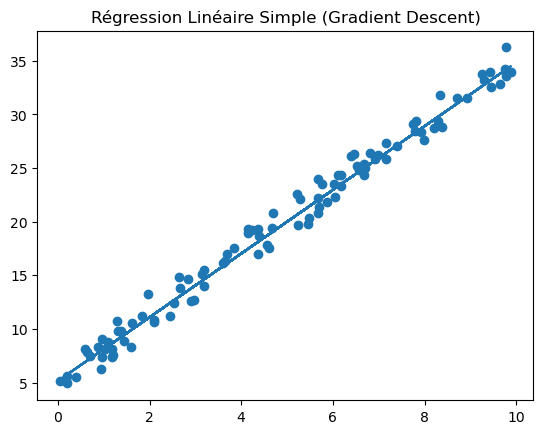


===== Régression Linéaire Multiple (GD) =====
Intercept: [9.5087241]
Coefficients: [2.06612013 3.10722272 4.17807129]
MSE: 4.477911799923077
R²: 0.945237007065693


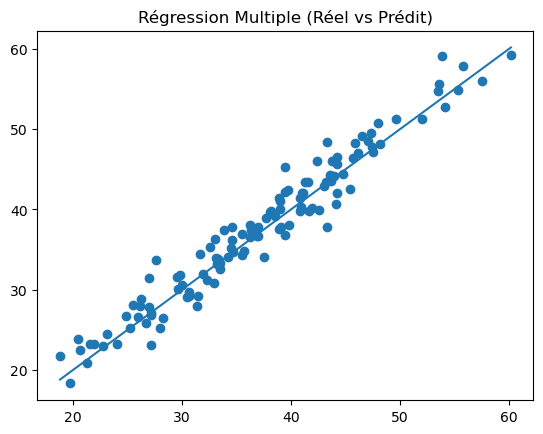


===== Régression Polynomiale (GD) =====
Intercept: [3.00493606]
Coefficients: [2.99725177 1.585082   1.65731837]
MSE: 519.191155205099
R²: 0.4373824371274031


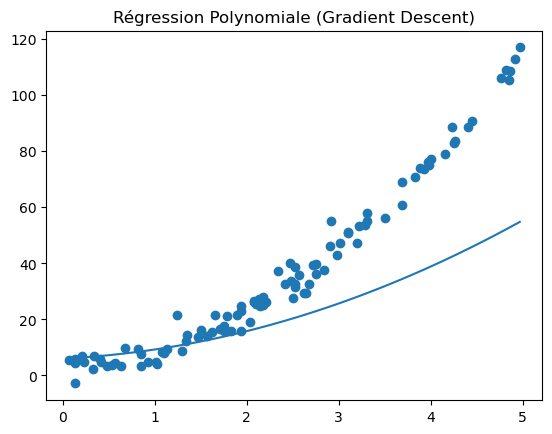

In [7]:
# =====================================================
# MACHINE LEARNING - GRADIENT DESCENT (LIBRARY)
# Régression Linéaire Simple, Multiple, Polynomiale
# =====================================================

# =========================
# IMPORTATION DES LIBRARIES
# =========================
import numpy as np                      # calcul numérique (tableaux, matrices)
import matplotlib.pyplot as plt        # visualisation graphique
from sklearn.linear_model import SGDRegressor   # modèle Gradient Descent
from sklearn.preprocessing import PolynomialFeatures  # transformation polynomiale
from sklearn.metrics import mean_squared_error, r2_score  # évaluation


# =====================================================
# 1. RÉGRESSION LINÉAIRE SIMPLE
# =====================================================

# -----------------------------
# DATASET
# -----------------------------
# X : variable explicative (ex : nombre d'heures d'étude)
# y : variable cible (ex : note obtenue)
# relation : y = 5 + 3X + bruit

np.random.seed(0)   # pour avoir les mêmes valeurs à chaque exécution

X = 10 * np.random.rand(100, 1)   # 100 valeurs entre 0 et 10
y = 5 + 3 * X + np.random.randn(100, 1)  # relation linéaire avec bruit

# -----------------------------
# MODÈLE (Gradient Descent)
# -----------------------------
model = SGDRegressor(
    max_iter=1000,        # nombre d'itérations
    eta0=0.01,            # learning rate (pas d'apprentissage)
    learning_rate='constant'  # taux constant
)

# entraînement du modèle
model.fit(X, y.ravel())   # y.ravel() → transformer en vecteur 1D

# prédiction
y_pred = model.predict(X)

# -----------------------------
# RÉSULTATS
# -----------------------------
print("\n===== Régression Linéaire Simple (GD) =====")
print("Intercept (b):", model.intercept_)   # constante
print("Coefficient (w):", model.coef_)      # pente
print("MSE:", mean_squared_error(y, y_pred))  # erreur moyenne
print("R²:", r2_score(y, y_pred))            # qualité du modèle

# -----------------------------
# VISUALISATION
# -----------------------------
plt.scatter(X, y)       # points réels
plt.plot(X, y_pred)     # droite prédite
plt.title("Régression Linéaire Simple (Gradient Descent)")
plt.show()


# =====================================================
# 2. RÉGRESSION LINÉAIRE MULTIPLE
# =====================================================

# -----------------------------
# DATASET
# -----------------------------
# X1 : heures d'étude
# X2 : heures de sommeil
# X3 : nombre de révisions
# y : note finale
# relation : y = 10 + 2X1 + 3X2 + 4X3 + bruit

np.random.seed(1)

n = 120   # nombre d'exemples

X1 = np.random.rand(n, 1) * 10   # variable 1
X2 = np.random.rand(n, 1) * 5    # variable 2
X3 = np.random.randint(1, 5, (n, 1))  # variable 3

# combiner les variables → matrice X
X = np.hstack((X1, X2, X3))

# variable cible
y = 10 + 2*X1 + 3*X2 + 4*X3 + np.random.randn(n, 1)*2

# -----------------------------
# MODÈLE (Gradient Descent)
# -----------------------------
model = SGDRegressor(max_iter=1000, eta0=0.01, learning_rate='constant')

model.fit(X, y.ravel())

# prédiction
y_pred = model.predict(X)

# -----------------------------
# RÉSULTATS
# -----------------------------
print("\n===== Régression Linéaire Multiple (GD) =====")
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)   # coefficients pour X1, X2, X3
print("MSE:", mean_squared_error(y, y_pred))
print("R²:", r2_score(y, y_pred))

# -----------------------------
# VISUALISATION
# -----------------------------
# comparer valeurs réelles vs prédictions
plt.scatter(y, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.title("Régression Multiple (Réel vs Prédit)")
plt.show()


# =====================================================
# 3. RÉGRESSION POLYNOMIALE
# =====================================================

# -----------------------------
# DATASET
# -----------------------------
# X : variable simple
# y : relation non linéaire
# y = 3 + 2X + 4X² + bruit

np.random.seed(2)

X = 5 * np.random.rand(100, 1)
y = 3 + 2*X + 4*(X**2) + np.random.randn(100, 1)*3

# -----------------------------
# TRANSFORMATION POLYNOMIALE
# -----------------------------
# transformer X → [1, X, X²]
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# -----------------------------
# MODÈLE (Gradient Descent)
# -----------------------------
model = SGDRegressor(max_iter=2000, eta0=0.01, learning_rate='constant')

model.fit(X_poly, y.ravel())

# prédiction
y_pred = model.predict(X_poly)

# -----------------------------
# RÉSULTATS
# -----------------------------
print("\n===== Régression Polynomiale (GD) =====")
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)   # correspond à [1, X, X²]
print("MSE:", mean_squared_error(y, y_pred))
print("R²:", r2_score(y, y_pred))

# -----------------------------
# VISUALISATION
# -----------------------------
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_range = model.predict(X_range_poly)

plt.scatter(X, y)
plt.plot(X_range, y_range)
plt.title("Régression Polynomiale (Gradient Descent)")
plt.show()